In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import yfinance as yf

ticker = 'AAPL'
df = yf.download(ticker, start='2020-01-01', end='2024-12-31')
df = df[['Close']]
df.dropna(inplace=True)
df.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2020-01-02,72.620834
2020-01-03,71.914841
2020-01-06,72.487846
2020-01-07,72.146935
2020-01-08,73.307533


In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df

array([[0.08941486],
       [0.08595442],
       [0.08876302],
       ...,
       [1.        ],
       [0.98322826],
       [0.96665203]])

In [6]:
# Step 4: Create Sequences (Sliding Window)
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

In [7]:
X, y = create_dataset(scaled_df)
X = X.reshape((X.shape[0], X.shape[1], 1))  # LSTM expects 3D input
print(X.shape, y.shape)

(1197, 60, 1) (1197,)


In [8]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error',metrics=['mean_absolute_error'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.fit(X_train,y_train,batch_size=64,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.1238 - mean_absolute_error: 0.2963 - val_loss: 0.0093 - val_mean_absolute_error: 0.0815
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0072 - mean_absolute_error: 0.0665 - val_loss: 0.0053 - val_mean_absolute_error: 0.0601
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0053 - mean_absolute_error: 0.0607 - val_loss: 0.0129 - val_mean_absolute_error: 0.1021
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0035 - mean_absolute_error: 0.0479 - val_loss: 0.0065 - val_mean_absolute_error: 0.0685
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0035 - mean_absolute_error: 0.0456 - val_loss: 0.0035 - val_mean_absolute_error: 0.0477
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0028 - mean_absolute_error: 0.0411 - val_loss: 0.0021 - val_mean_absolute_error: 0.0368
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0030 - mean_absolute_error: 0.0430 - val_loss

In [24]:
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted.reshape(-1, 1))
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


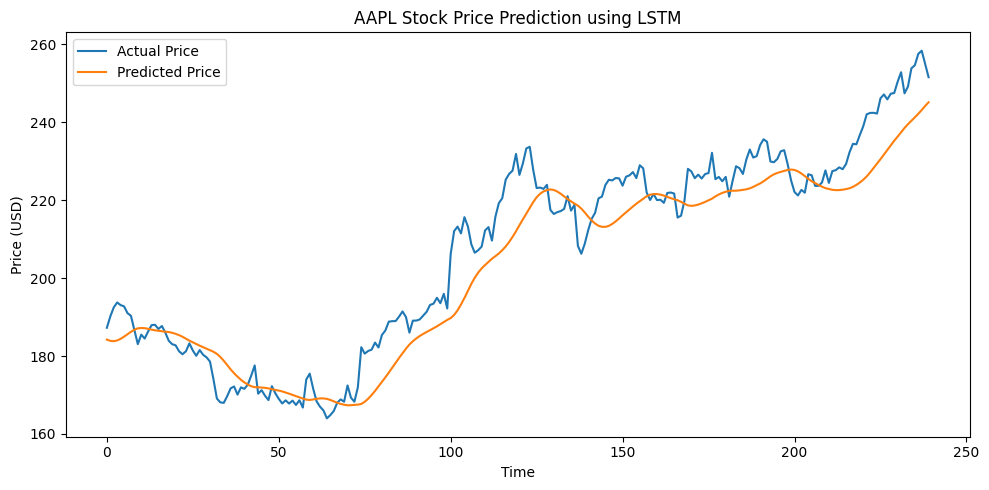

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title(f'{ticker} Stock Price Prediction using LSTM')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()